In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "agent_id": range(1, n+1),
    "calls_handled": np.random.randint(50, 300, n),
    "avg_talk_time": np.random.uniform(2, 15, n),
    "sales": np.random.randint(5, 80, n),
    "csat_score": np.random.uniform(2.5, 5.0, n),
    "absenteeism_days": np.random.randint(0, 10, n),
    "tenure_months": np.random.randint(1, 60, n)
})

# Create conversion rate
data["conversion_rate"] = data["sales"] / data["calls_handled"]

# Create PCP logic (realistic patterns)
data["pcp_status"] = (
    (data["conversion_rate"] < 0.15) &
    (data["csat_score"] < 3.5) |
    (data["absenteeism_days"] > 6)
).astype(int)

data.to_csv("call_center_data.csv", index=False)

data.head()

,agent_id,calls_handled,avg_talk_time,sales,csat_score,absenteeism_days,tenure_months,conversion_rate,pcp_status
0,1,152,6.662408,31,2.756274,8,52,0.203947,1
1,2,229,5.304127,59,4.843071,5,28,0.257642,0
2,3,142,5.838778,37,4.219714,0,14,0.260563,0
3,4,64,6.193160,72,2.669593,3,27,1.125000,0
4,5,156,13.032707,70,3.252409,0,41,0.448718,0


In [2]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   agent_id          500 non-null    int64  
 1   calls_handled     500 non-null    int64  
 2   avg_talk_time     500 non-null    float64
 3   sales             500 non-null    int64  
 4   csat_score        500 non-null    float64
 5   absenteeism_days  500 non-null    int64  
 6   tenure_months     500 non-null    int64  
 7   conversion_rate   500 non-null    float64
 8   pcp_status        500 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 35.3 KB


In [3]:
# Summary statistics
data.describe()

,agent_id,calls_handled,avg_talk_time,sales,csat_score,absenteeism_days,tenure_months,conversion_rate,pcp_status
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,250.500000,178.296000,8.511843,41.970000,3.755038,4.53000,30.044000,0.289454,0.384000
std,144.481833,71.772802,3.700290,21.216441,0.726893,2.80443,16.862822,0.236514,0.486845
min,1.000000,50.000000,2.033735,5.000000,2.512350,0.00000,1.000000,0.017986,0.000000
25%,125.750000,113.750000,5.302563,24.000000,3.093860,2.00000,15.000000,0.134007,0.000000
50%,250.500000,179.000000,8.662391,42.000000,3.788017,4.00000,29.500000,0.224814,0.000000
75%,375.250000,239.000000,11.581674,60.000000,4.341300,7.00000,45.000000,0.368421,1.000000
max,500.000000,299.000000,14.970004,79.000000,4.998534,9.00000,59.000000,1.529412,1.000000


In [4]:
# Check how many agents are on PCP
data['pcp_status'].value_counts()

,count
pcp_status,
0,308
1,192


In [5]:
# Compare averages between PCP and Non-PCP agents
data.groupby('pcp_status').mean()

,agent_id,calls_handled,avg_talk_time,sales,csat_score,absenteeism_days,tenure_months,conversion_rate
pcp_status,,,,,,,,
0,245.62987,174.957792,8.352722,43.892857,3.903538,3.090909,29.519481,0.309399
1,258.31250,183.651042,8.767100,38.885417,3.516819,6.838542,30.885417,0.257458


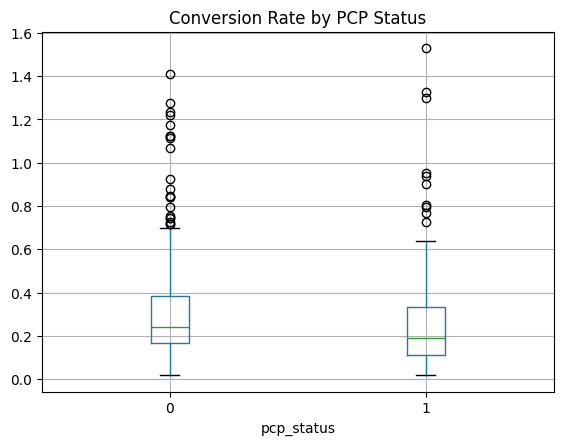

In [6]:
import matplotlib.pyplot as plt

# Compare conversion rate
data.boxplot(column='conversion_rate', by='pcp_status')
plt.title('Conversion Rate by PCP Status')
plt.suptitle('')
plt.show()

<Axes: title={'center': 'avg_talk_time'}, xlabel='pcp_status'>

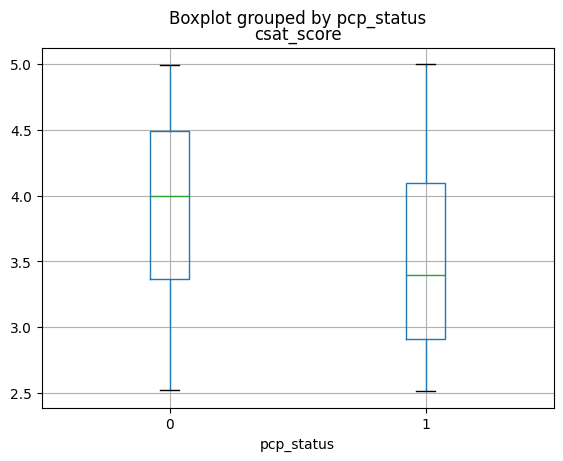

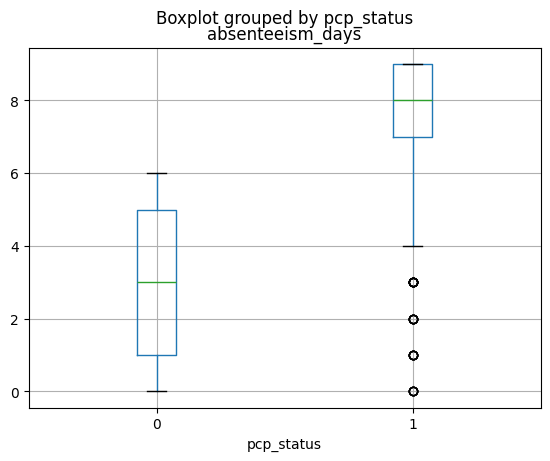

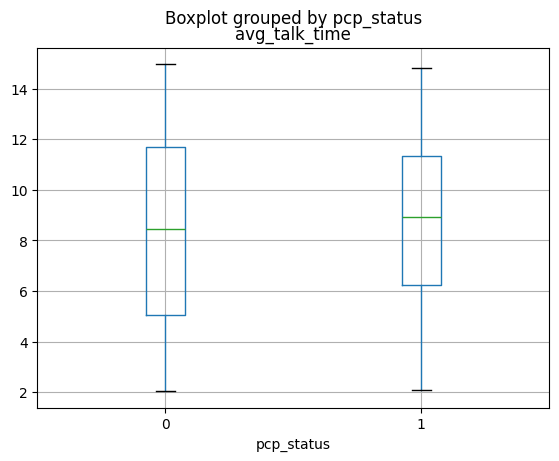

In [7]:
# CSAT
data.boxplot(column='csat_score', by='pcp_status')

# Absenteeism
data.boxplot(column='absenteeism_days', by='pcp_status')

# Talk time
data.boxplot(column='avg_talk_time', by='pcp_status')

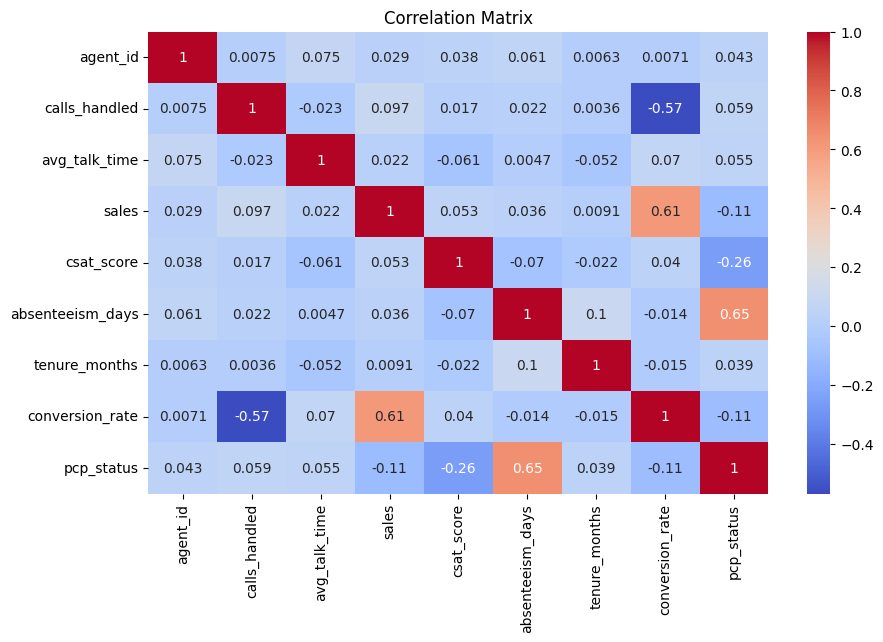

In [8]:
# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Features and target
X = data.drop(columns=['agent_id', 'pcp_status'])
y = data['pcp_status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        60
           1       0.74      0.70      0.72        40

    accuracy                           0.78       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.78      0.78      0.78       100



In [10]:
# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,absenteeism_days,0.979011
6,conversion_rate,0.094632
1,avg_talk_time,0.076156
0,calls_handled,0.004244
5,tenure_months,-0.016754
2,sales,-0.036027
3,csat_score,-1.511766
